In [ ]:
import scipy.io

# .mat 파일 로드
mat = scipy.io.loadmat('meas_gre_dir1.mat')

# 파일 내용 확인
print(mat.keys())  # 변수 확인



<class 'dict'>
dict_keys(['__header__', '__version__', '__globals__', 'B0_dir', 'CF', 'delta_TE', 'mask_brain', 'meas_gre', 'te_gre', 'tolvalue', 'voxel_size_gre'])


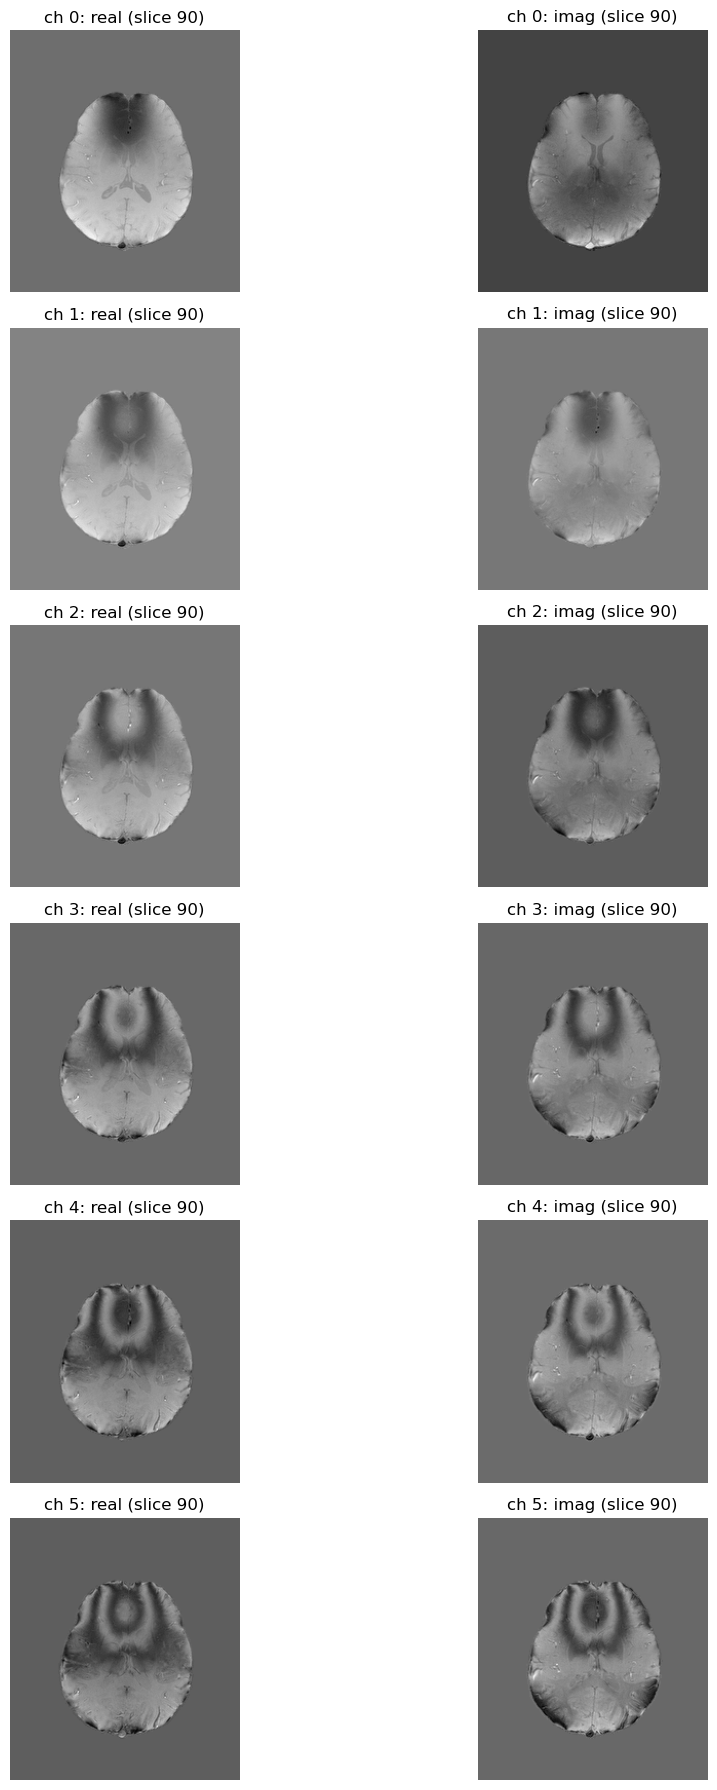

In [2]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# 1. .mat 파일 불러오기
mat_data = sio.loadmat('meas_gre_dir1.mat')

# 2. 필요한 변수 추출
meas_gre = mat_data['meas_gre']  # shape: (256, 224, 176, 6)

# 3. 확인할 슬라이스 선택 (3번째 차원의 중간 슬라이스)
slice_idx = 90 #  176 까지의 숫자 중 하나

# 4. 채널 개수 확인 => 6개임
num_channels = meas_gre.shape[3]

# 5. 각 채널의 실수부와 허수부를 한 화면에 표시
plt.figure(figsize=(12, num_channels * 3))
for ch in range(num_channels):
    # 각 채널의 선택한 슬라이스의 실수부, 허수부 추출
    real_part = np.real(meas_gre[:, :, slice_idx, ch])
    imag_part = np.imag(meas_gre[:, :, slice_idx, ch])
    
    # 실수부 이미지: 각 채널 별로 한 행의 왼쪽
    plt.subplot(num_channels, 2, ch * 2 + 1)
    plt.imshow(real_part, cmap='gray')
    plt.title(f'ch {ch}: real (slice {slice_idx})')
    plt.axis('off')
    
    # 허수부 이미지: 각 채널 별로 한 행의 오른쪽
    plt.subplot(num_channels, 2, ch * 2 + 2)
    plt.imshow(imag_part, cmap='gray')
    plt.title(f'ch {ch}: imag (slice {slice_idx})')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [12]:
import scipy.io as sio
import numpy as np
import napari

# 1. .mat 파일 불러오기
mat_data = sio.loadmat('meas_gre_dir1.mat')
meas_gre = mat_data['meas_gre']  # shape: (256, 224, 176, 6)

# 2. 분석할 채널 선택 (예: 채널 0)
channel = 1

# 3. 3D 볼륨 데이터 추출
# 실수부, 허수부, 그리고 크기(절댓값)를 각각 추출합니다.
real_vol = np.real(meas_gre[:, :, :, channel])
imag_vol = np.imag(meas_gre[:, :, :, channel])
mag_vol  = np.abs(meas_gre[:, :, :, channel])

# 4. napari 뷰어 생성 및 3D 볼륨 추가
viewer = napari.Viewer()
viewer.add_image(real_vol, name='Real Volume', colormap='gray', blending='additive')
viewer.add_image(imag_vol, name='Imaginary Volume', colormap='gray', blending='additive')
viewer.add_image(mag_vol,  name='Magnitude Volume', colormap='gray', blending='additive')

napari.run()



meas_gre shape: (256, 224, 176, 6)
mask_brain shape: (256, 224, 176)


/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52292 (\N{HANGUL SYLLABLE CAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 45328 (\N{HANGUL SYLLABLE NEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/py

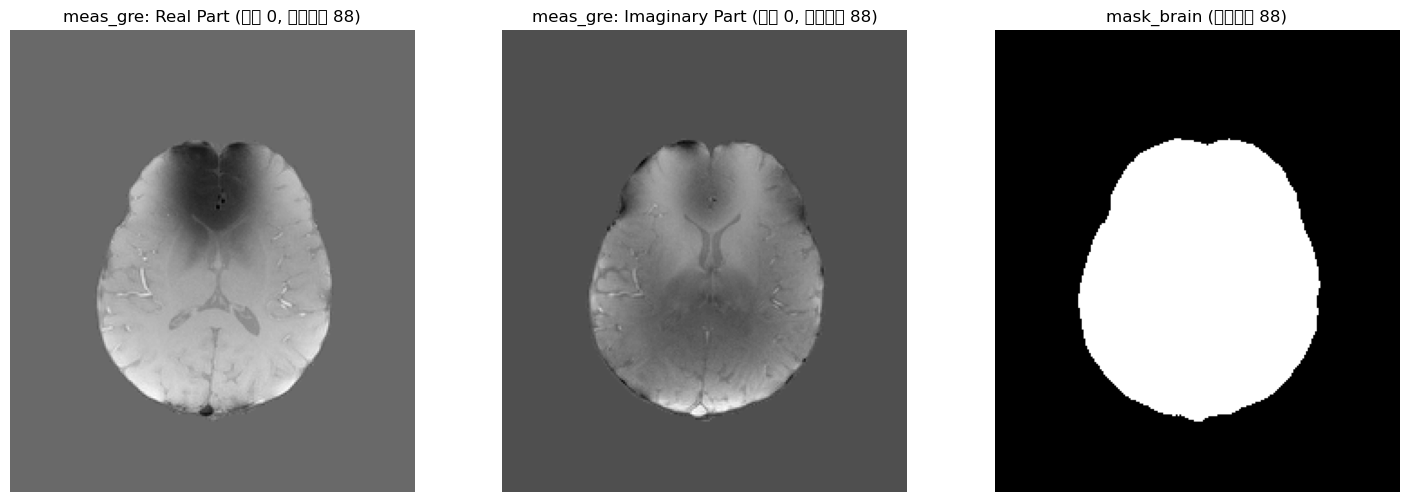

In [5]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# .mat 파일 불러오기 (파일 경로를 자신의 파일명으로 변경)
mat_data = sio.loadmat('meas_gre_dir1.mat')

# 변수 추출
meas_gre = mat_data['meas_gre']
mask_brain = mat_data['mask_brain']

# 데이터 shape 출력
print("meas_gre shape:", meas_gre.shape)
print("mask_brain shape:", mask_brain.shape)

# 예시로 중간 슬라이스를 선택 (3번째 차원)
slice_idx = meas_gre.shape[2] // 2  # 중간 인덱스
channel = 0  # 첫 번째 채널 선택

# 실수부와 허수부 추출 (2D 슬라이스)
real_part = np.real(meas_gre[:, :, slice_idx, channel])
imag_part = np.imag(meas_gre[:, :, slice_idx, channel])
mask_slice = mask_brain[:, :, slice_idx]

# 시각화
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(real_part, cmap='gray')
plt.title('meas_gre: Real Part (채널 0, 슬라이스 {})'.format(slice_idx))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(imag_part, cmap='gray')
plt.title('meas_gre: Imaginary Part (채널 0, 슬라이스 {})'.format(slice_idx))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mask_slice, cmap='gray')
plt.title('mask_brain (슬라이스 {})'.format(slice_idx))
plt.axis('off')

plt.show()
